part1
electric.csv
1. 케라스, tensorflow 학습
2. scotter와 예측선
3. 전기생산량 4, 5인 경우 전기사용량 예측
4. 결정계수( sklearn 이용 )

part2
trees.csv
1. 케라스학습
2. 예측값, 실제값 plot
3. 11.1, 80 인경우 volume 예측
4. 결정계수

In [107]:
import tensorflow as tf
from keras.optimizers import Adam
from keras import Sequential
from keras.layers import Dense
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

### part1

In [ ]:
df_e = pd.read_csv('data/electric.csv', index_col=0)

In [109]:
x = df_e['전기사용량'].values
y = df_e['전기생산량'].values

#### tensorflow

In [110]:
w = tf.Variable( tf.random.uniform([1]) )
b = tf.Variable( tf.random.uniform([1]) )

In [111]:
lr = 0.01

for i in range(2000):
    with tf.GradientTape() as tape:
        hx = w + b
        cost = tf.reduce_mean( (hx - y)**2 )
    
    w_grad, b_grad = tape.gradient( cost, [w, b] )
    w.assign_sub(lr*w_grad)
    b.assign_sub(lr*b_grad)
    print('cost', cost.numpy())

cost 9.880308
cost 9.137267
cost 8.452482
cost 7.8213844
cost 7.2397647
cost 6.703743
cost 6.2097454
cost 5.754477
cost 5.3349037
cost 4.948223
cost 4.5918584
cost 4.263433
cost 3.9607563
cost 3.6818092
cost 3.4247315
cost 3.187809
cost 2.9694607
cost 2.7682314
cost 2.5827782
cost 2.4118645
cost 2.254351
cost 2.109186
cost 1.9754022
cost 1.8521069
cost 1.7384778
cost 1.6337575
cost 1.5372471
cost 1.4483032
cost 1.3663327
cost 1.2907883
cost 1.2211667
cost 1.1570034
cost 1.0978703
cost 1.0433737
cost 0.9931496
cost 0.94686294
cost 0.904205
cost 0.8648917
cost 0.8286604
cost 0.7952697
cost 0.764497
cost 0.7361367
cost 0.70999986
cost 0.6859121
cost 0.6637129
cost 0.6432541
cost 0.62439924
cost 0.6070226
cost 0.59100825
cost 0.5762494
cost 0.56264764
cost 0.5501122
cost 0.53855973
cost 0.5279129
cost 0.5181008
cost 0.509058
cost 0.5007241
cost 0.4930435
cost 0.48596525
cost 0.4794418
cost 0.47342983
cost 0.46788916
cost 0.46278295
cost 0.45807704
cost 0.45374003
cost 0.449743
cost 0.44605

In [112]:
print('최종w', w.numpy())
print('최종b', b.numpy())

최종w [1.6305504]
최종b [2.2544467]


#### 케라스

In [113]:
dense = Dense( units=1, input_dim=1 )
model = Sequential( [dense] )
model.compile( loss='mse', optimizer=Adam(0.1) )
model.fit( x, y, epochs=500 )

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 73.1163
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 66.6718
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 60.5343
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 54.7086
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 49.1987
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 44.0078
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 39.1378
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 34.5896
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 30.3628
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 26.4558
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 22.8653
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 19.5868
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 16.6142
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 13.9398
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 11.5544
Epoch 16/500
1/

In [114]:
w, b = dense.get_weights()
print( w )
print( b )

[[0.9097626]]
[1.3192458]


In [115]:
y_pred_e = model.predict( x )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


In [116]:
model.predict(np.array([4]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[4.9582963]], dtype=float32)

In [117]:
model.predict(np.array([5]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


array([[5.8680587]], dtype=float32)

#### scatter

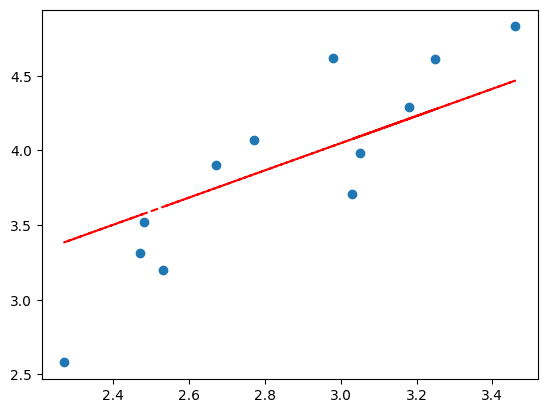

In [118]:
plt.scatter( x, y )
plt.plot( x, y_pred_e, 'r--' )

#### 결정계수

In [119]:
score = r2_score( y , y_pred_e )
score

0.6455292933559695

### part2

In [ ]:
df_t = pd.read_csv('data/trees.csv')

In [121]:
x = df_t.iloc[:,:-1].values
y = df_t.iloc[:,-1].values

#### 케라스

In [ ]:
x.shape

(31, 2)

In [123]:
dense = Dense( units=1, input_dim=2 )
model = Sequential( [dense] )
model.compile( loss='mse', optimizer=Adam(0.1) )
model.fit( x, y, epochs=500 )

Epoch 1/500


c:\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 6881.1440
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 5473.7441
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 4236.1191
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 3170.0608
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 2275.4905
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 1549.8735
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 987.6562
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 579.6780
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 312.6975
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 169.2159
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 127.7650
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 163.8256
Epoch 13/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 251.4007
Epoch 14/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 365.0691
Epoch 15/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 482

In [124]:
w, b = dense.get_weights()
print( w )
print( b )

[[ 4.6431684 ]
 [-0.38546357]]
[-1.6385866]


In [144]:
dense(x)

<tf.Tensor: shape=(31, 1), dtype=float32, numpy=
array([[ 9.917262],
       [13.237533],
       [14.937091],
       [19.361307],
       [16.820765],
       [16.514158],
       [23.99567 ],
       [20.526499],
       [19.063501],
       [21.455133],
       [20.377596],
       [21.9983  ],
       [21.9983  ],
       [26.089497],
       [25.169668],
       [29.73398 ],
       [25.49388 ],
       [26.965689],
       [34.604908],
       [37.767464],
       [33.29961 ],
       [33.457317],
       [37.16305 ],
       [44.89873 ],
       [44.364357],
       [47.465675],
       [48.008846],
       [50.637043],
       [51.10136 ],
       [51.10136 ],
       [60.47535 ]], dtype=float32)>

In [139]:
y_pred_t = model.predict( x )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


#### 예측값, 실제값 plot

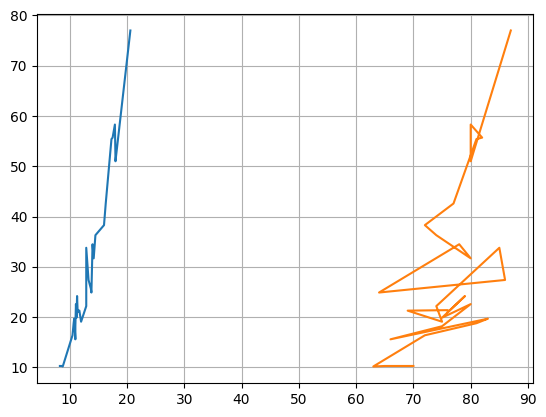

In [ ]:
plt.scatter(y, y_pred_t)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # 기준선
plt.grid(True)
plt.show()

#### Volume 예측 (11.1, 80)

In [128]:
model.predict( np.array([[11.1, 80]]) )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[19.063501]], dtype=float32)

#### 결정 계수

In [129]:
score_t = r2_score( y, y_pred_t)
score_t

0.8646171947733301